# [LAB 11] 3. 분해 시계열이란
## #01. 준비작업
### 1. 라이브러리 참조

In [1]:
# 라이브러리 기본 참조
from hossam import load_data
from helpers import *

from pandas import DataFrame
import numpy as np
import seaborn as sb

# 시계열 분해
from statsmodels.tsa.seasonal import seasonal_decompose

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.5.31


### 2. 데이터 불러오기 + 시계열 인덱스 설정

In [2]:
origin = load_data('air_passengers')

# 월단위 데이터임을 알림 --> freq='MS' (Month Start)
df = my_ts.set_index(origin, 'Month', freq='MS')
print('인덱스 간격(freq):', df.index.freqstr)
df.head()

📚 어느 항공사의 월간 탑승객 수 (출처: https://www.kaggle.com/datasets/rakannimer/air-passengers)
인덱스 간격(freq): MS


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


![alt text](image-15.png)
![alt text](image-16.png)

## #02. 분해 시계열
### 1. 어떤 모델을 쓸 것인가? - 데이터로 판단하기
- 연도별 변동폭이 커지는지 확인하면 된다
    - 1단원에서 만든 report_variation() 함수가 이 질문에도 그대로 답한다.
    
    ![alt text](image-17.png)

In [3]:
# 기간단위(기본 freq='YE' -> 연단위)로 묶어 평균, 표준편차, 변동계수를 계산한다.
# 변동계수 = 표준편차 / 평균, 승법이면 이 값이 일정하다.
# 판정 문장은 함수가 출력하고, 표는 반환되므로 마지막 줄에 놓아 화면에 띄운다.
my_ts.report_variation(df, 'Passengers', freq='YE')

표준편차 최대/최소: 5.67배
변동계수 최대/최소: 1.56배
판정: 변동폭이 수준에 비례한다 → 로그변환 권장 / 승법(multiplicative) 모델


,평균,표준편차,변동계수
기간,,,
1949-12-31,126.667,13.720,0.108
1950-12-31,139.667,19.071,0.137
1951-12-31,170.167,18.438,0.108
1952-12-31,197.000,22.966,0.117
1953-12-31,225.000,28.467,0.127
1954-12-31,238.917,34.924,0.146
1955-12-31,284.000,42.140,0.148
1956-12-31,328.250,47.862,0.146
1957-12-31,368.417,57.891,0.157


![alt text](image-18.png)

### 2. 분해 시계열 생성
- statsmodels의 seasonal_decompose()가 세 성분(추세, 계절, 잔차)을 한번에 계산한다.
    - model파라미터에 가법모델(additive) 또는 승법모델(multiplicative) 여부를 지정해야 함
- 분해는 차분하기 전의 원본으로 하는 것이 원칙이다. 차분은 추세와 계절성을 지우는 작업인데, 분해는 그 추세와 계절성을 보려는 것이기 때문이다.

In [4]:
# 분해 수행 --> 분해할 시계열, 모델 유형(승법/가법), 계절 주기(period)
# 반환값은 'observed', 'trend', 'seasonal', 'resid' 네 개의 Seried를 속성으로 가진 객체
result = seasonal_decompose(df['Passengers'], model='multiplicative', period=12)

# 비교와 저장이 편하도록 데이터프레임 하나로 묶어서 사용(인덱스는 원본과 동일)
sd = DataFrame({
    'original':result.observed,  #원본시계열
    'trend':result.trend,       #추세 성분(장기적 방향)
    'seasonal':result.seasonal,  # 계절 성분(주기적 반복)
    'resid' : result.resid       # 잔차 성분(설명되지 않는 변동)
})

sd.dropna()

,original,trend,seasonal,resid
Month,,,,
1949-07-01,148.000,126.792,1.227,0.952
1949-08-01,148.000,127.250,1.220,0.953
1949-09-01,136.000,127.958,1.060,1.002
1949-10-01,119.000,128.583,0.922,1.004
1949-11-01,104.000,129.000,0.801,1.006
...,...,...,...,...
1960-02-01,391.000,461.375,0.884,0.959
1960-03-01,419.000,465.208,1.007,0.894
1960-04-01,461.000,469.333,0.976,1.006


- trend와 resid 앞뒤 6개월은 결측치다.
- 추세를 12개월 이동평균으로 계산하므로 양끝에서는 평균 낼값이 부족하기 때문이다.
- sd.dropna()로 확인하면 144개월 중 132개월만 남는다.

### 3. 분해된 성분 시각화

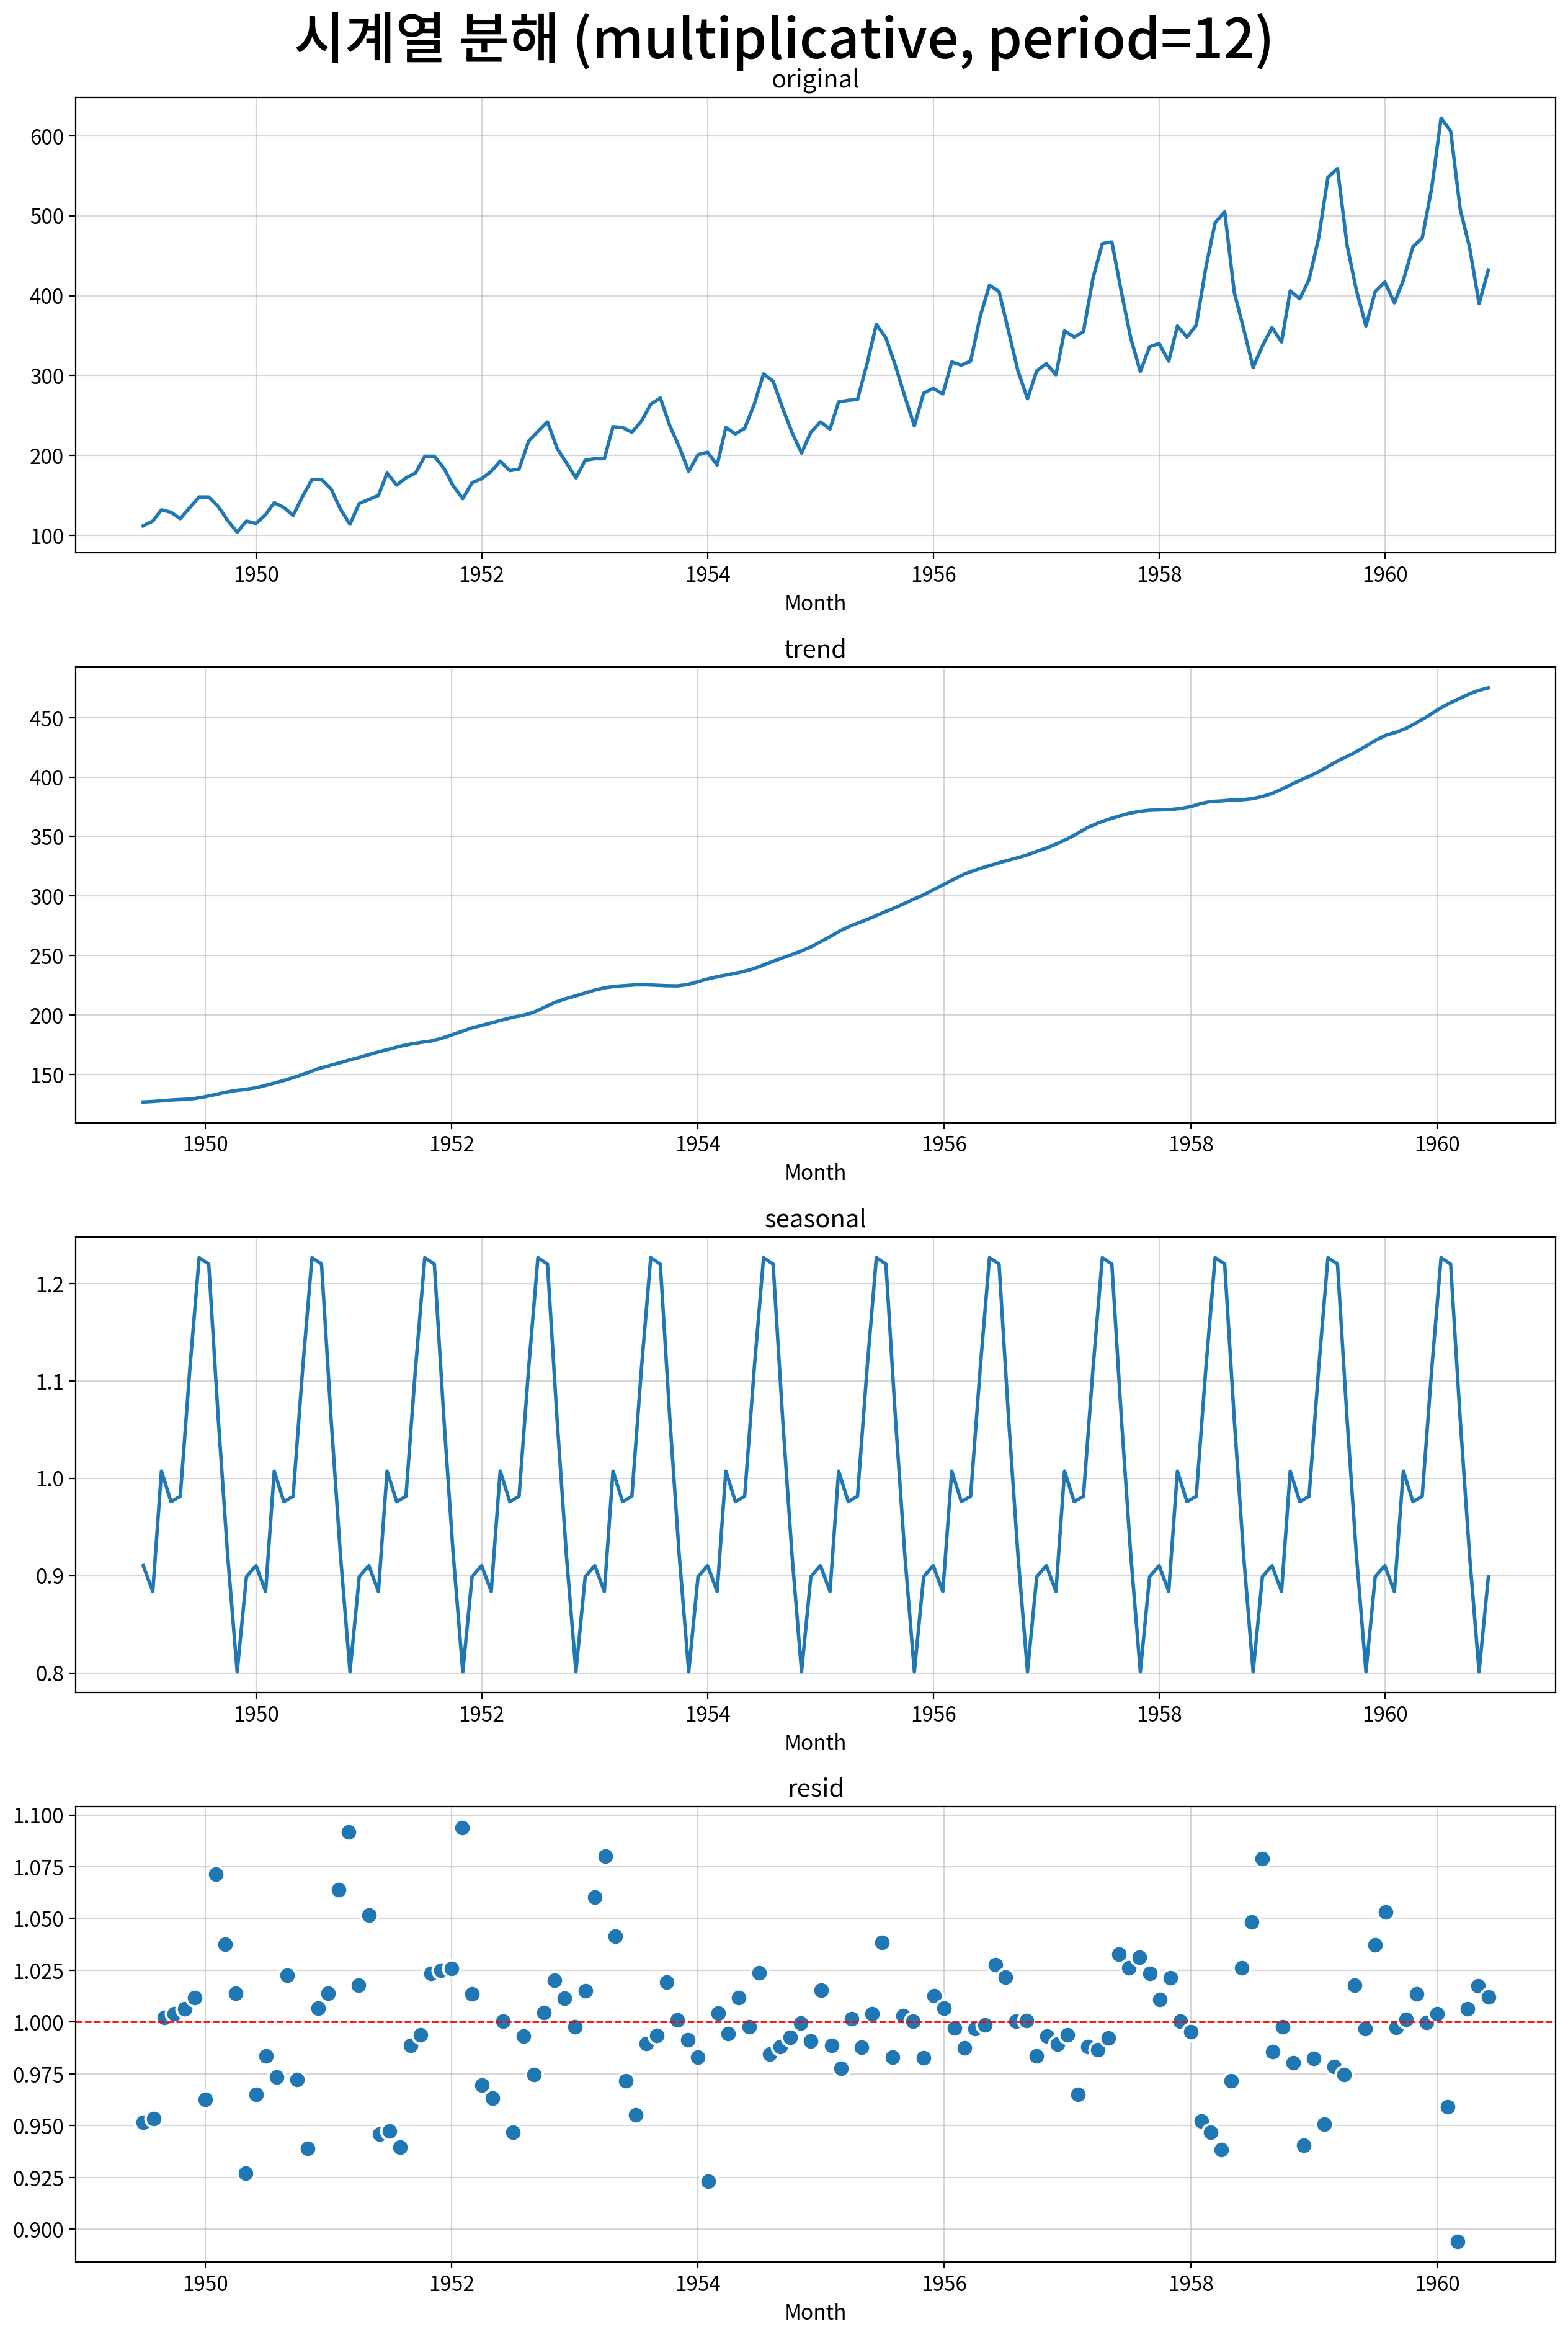

In [5]:
# 성분별로 한 단씩, 4단 그래프로 그린다
fig, ax = my_plot.init(rows=4, cols=1, width=1280, height=480, title='시계열 분해 (multiplicative, period=12)')

for i, col in enumerate(sd.columns):
    if col == 'resid':
        # 잔차는 불규칙하므로 점으로 그려야 남은 패턴이 보인다
        my_plot.scatterplot(data=sd, x=sd.index, y=col, ax=ax[i])
    else:
        my_plot.lineplot(x=sd.index, y=sd[col], ax=ax[i])

    ax[i].set_title(col)
    ax[i].set_ylabel("")

# 승법 모델의 잔차 기준선은 1(가법 모델이면 0)
ax[3].axhline(1, color='red', linestyle='--', linewidth=1)

my_plot.show()

- 승법모델이므로 계절 성분은 배수로 읽는다. seasonal=1.227은 추세선보다 22.7% 높다는 뜻
- 잔차가 1 주변에 몰려 있으면 분해가 잘된 신호
- 패던이 남아있다면 주기를 잘못 잡았거나 모델 선택이 틀린 것

## #03. 분해 시계열의 특성
### 1. 추세와 이동평균 비교(1) - 이동평균 구하기
- 앞의 내용에서 추세는 이동평균(창=계절주기)으로 계산한다고 했다
    - 2단원에서 만든 my_ts.plot_rolling()으로 직접 확인해보자

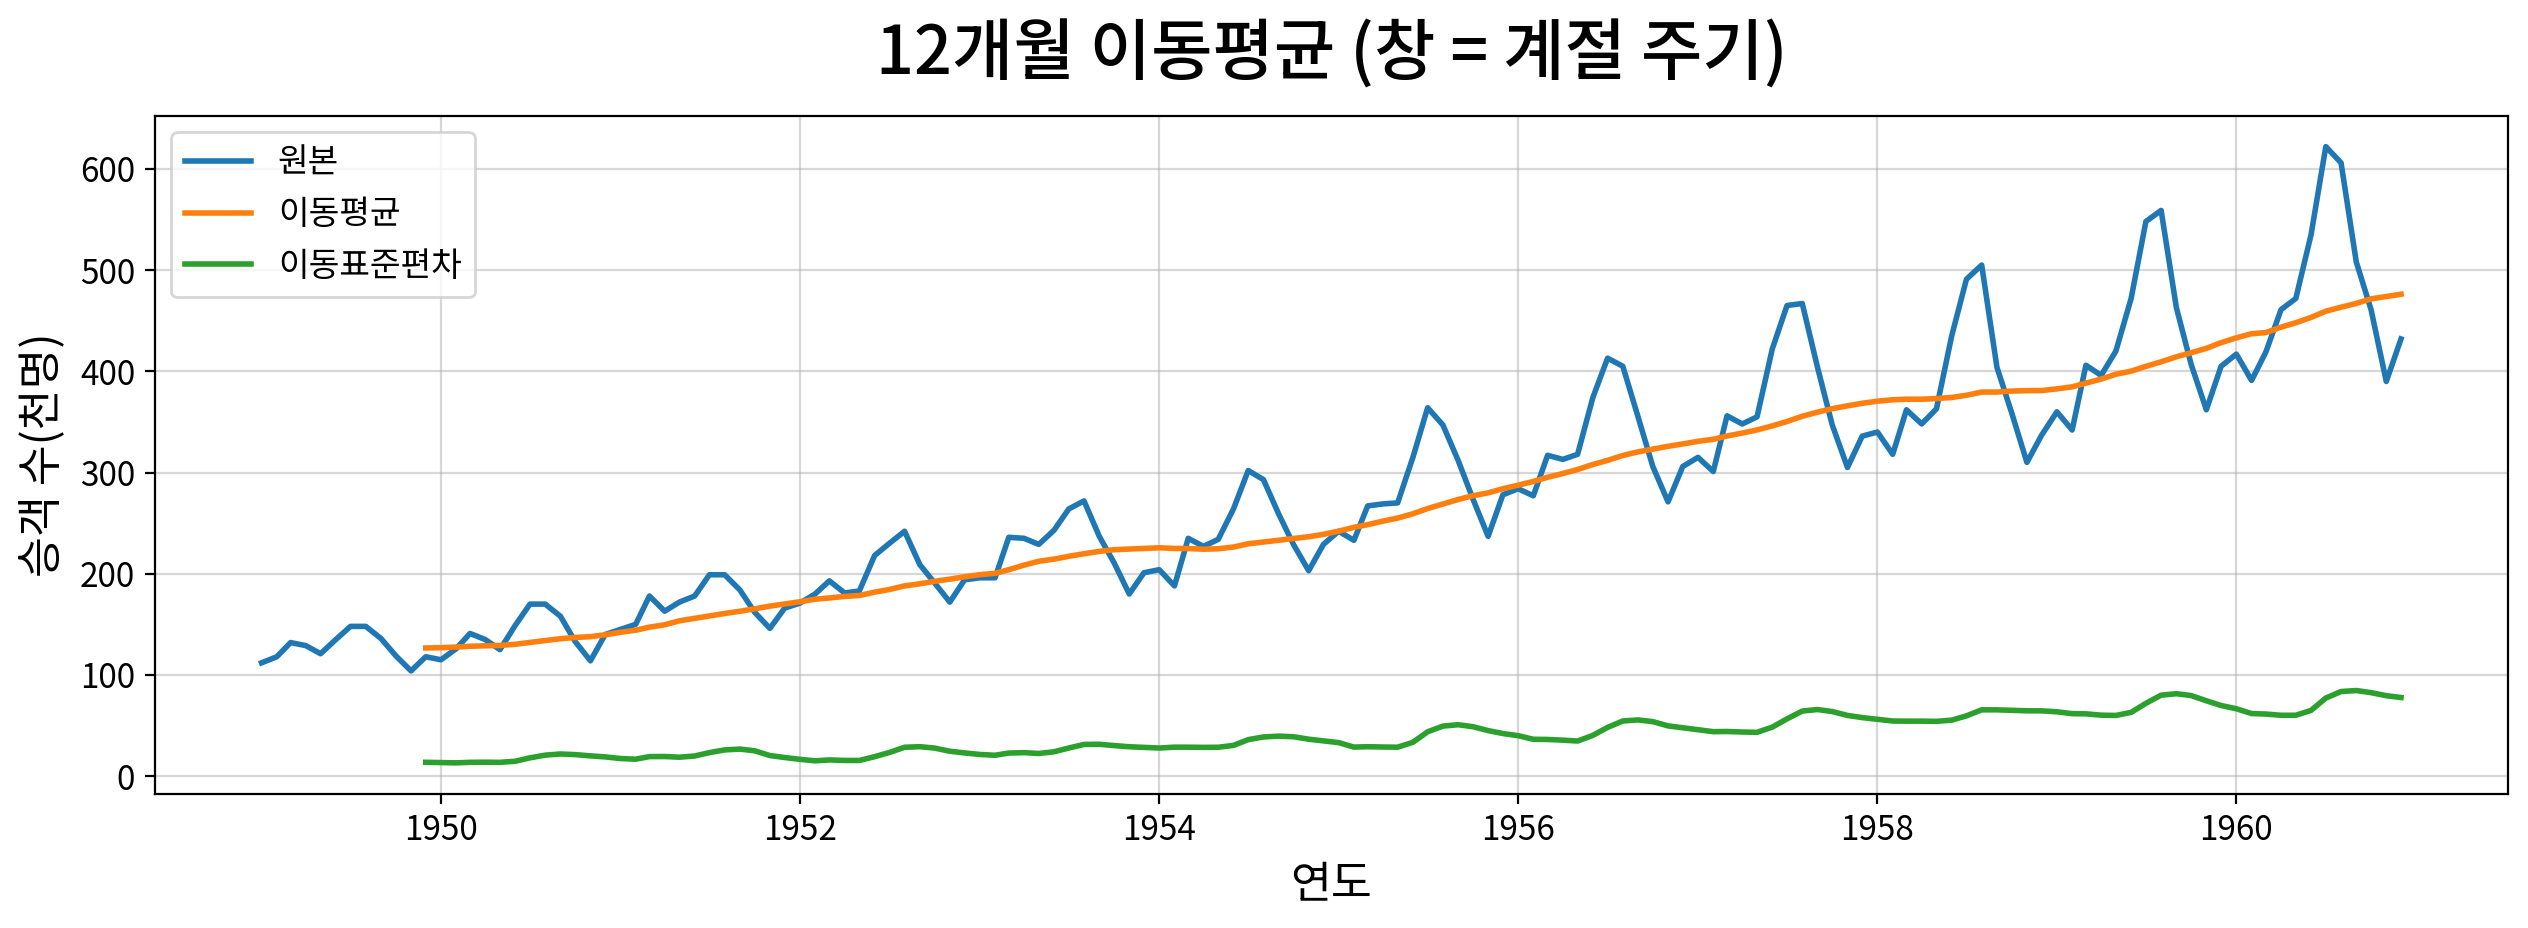

,원본,이동평균,이동표준편차
Month,,,
1949-01-01,112,NaN,NaN
1949-02-01,118,NaN,NaN
1949-03-01,132,NaN,NaN
1949-04-01,129,NaN,NaN
1949-05-01,121,NaN,NaN


In [6]:
# 2단원에서 만든 함수로 12개월 이동평균을 구한다.
# --> 리턴값이 이동평균이 계산된 데이터프레임
rolling = my_ts.plot_rolling(df, 12, 'Passengers', title='12개월 이동평균 (창 = 계절 주기)',
                             xlabel='연도', ylabel='승객 수(천명)')

rolling.head()

### 2. 추세와 이동평균 비교(2) - 추세와 이동평균의 상관계수 확인

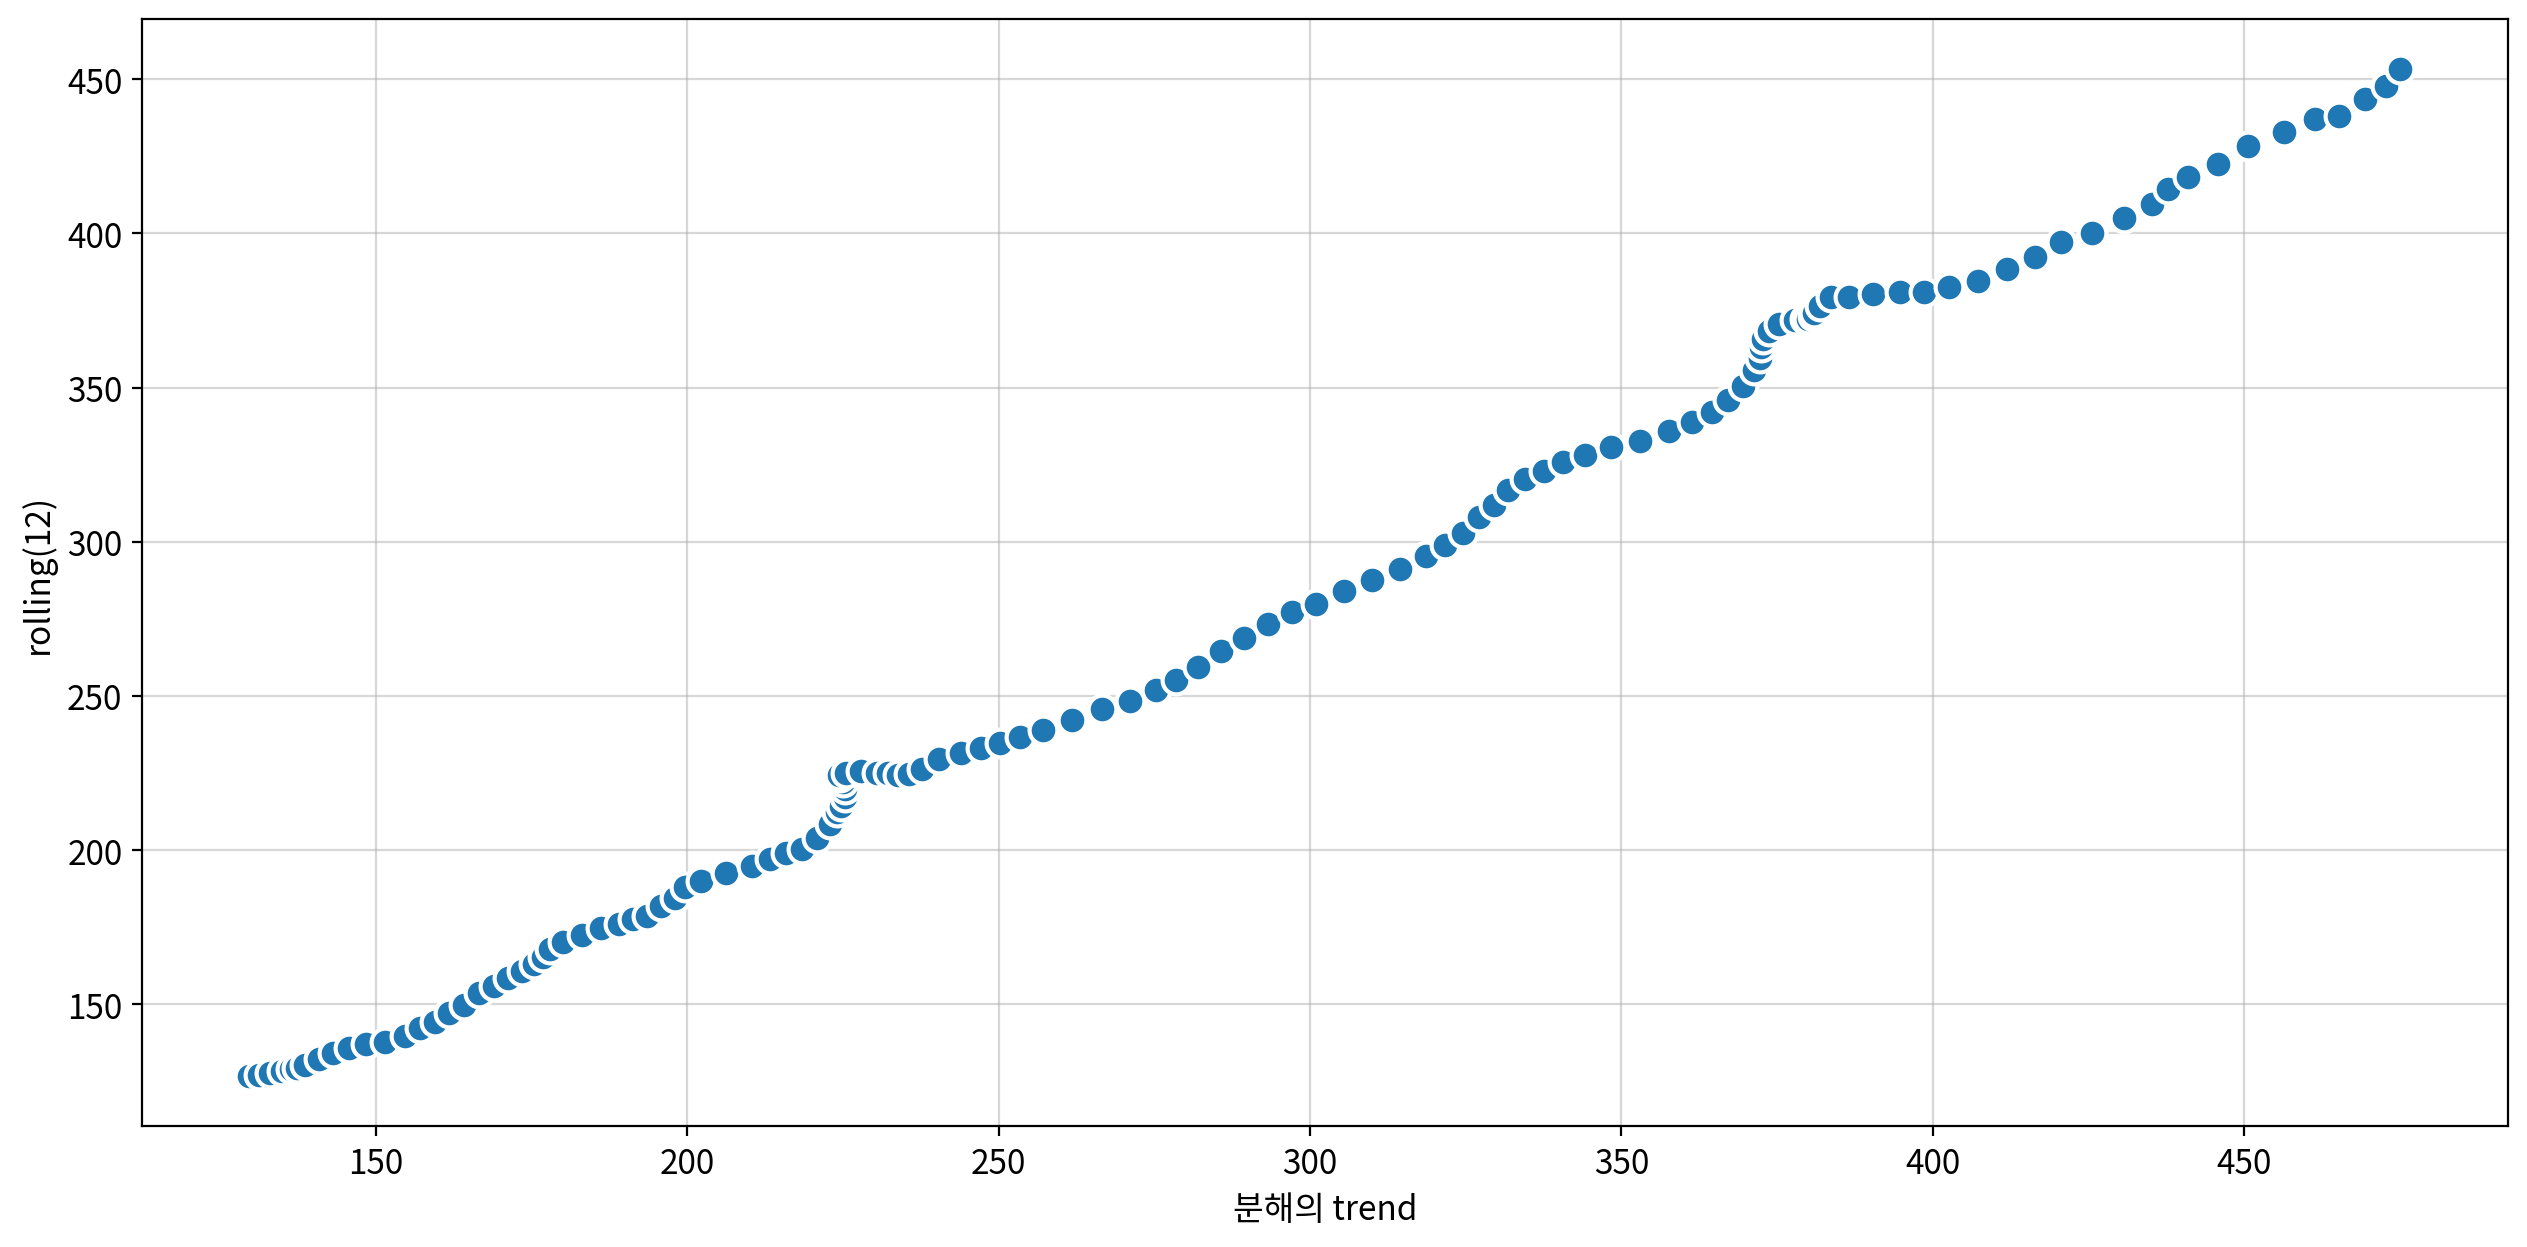

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
분해의 trend,rolling(12),Spearman,1.000,0.000,Strong,True,False,False,True,False,False


In [9]:
# 분해가 내놓은 추세 성분과 나란히 놓고 비교한다
check = DataFrame({
    "분해의 trend" : sd['trend'],
    'rolling(12)':rolling['이동평균']
})

# 두 값의 상관계수 확인
my_stats.correlation(check, '분해의 trend', 'rolling(12)')

### 3. 계절 성분의 특성(1)
- 계절 성분은 매년 똑같이 반복되므로, 1년치만 뽑아 보면 전체를 알 수 있다

In [11]:
# 계절 성분에서 1년치(12개월)만 추출하여 월별로 정리
season = sd['seasonal'].groupby(sd.index.month).first()
season.index.name = '월'
sdf =DataFrame({'계절지수':season.round(4)})

# 계절지수의 평균은 1이어야 한다.(승법모델기준)
sdf['평균'] = season.mean().round(4)

# 승법모델은 원본 = 추세 x 계절 x 잔차이므로 계절지수는 배수이다.
# 기준점이 1(=추세와 똑같음)이므로 1을 빼면 기준에서 얼마나 벗어났는지가 되고, x100하면 백분율이 된다. 즉, 추세 대비 몇% 증감인지를 의미한다.
sdf['추세 대비'] = ((season - 1) * 100).round(1).astype(str) + '%'

sdf.T

월,1,2,3,4,5,6,7,8,9,10,11,12
계절지수,0.910,0.884,1.007,0.976,0.981,1.113,1.227,1.220,1.060,0.922,0.801,0.899
평균,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
추세 대비,-9.0%,-11.6%,0.7%,-2.4%,-1.9%,11.3%,22.7%,22.0%,6.0%,-7.8%,-19.9%,-10.1%


### 4. 계절 성분의 특성(2) - 추세 대비 시각화

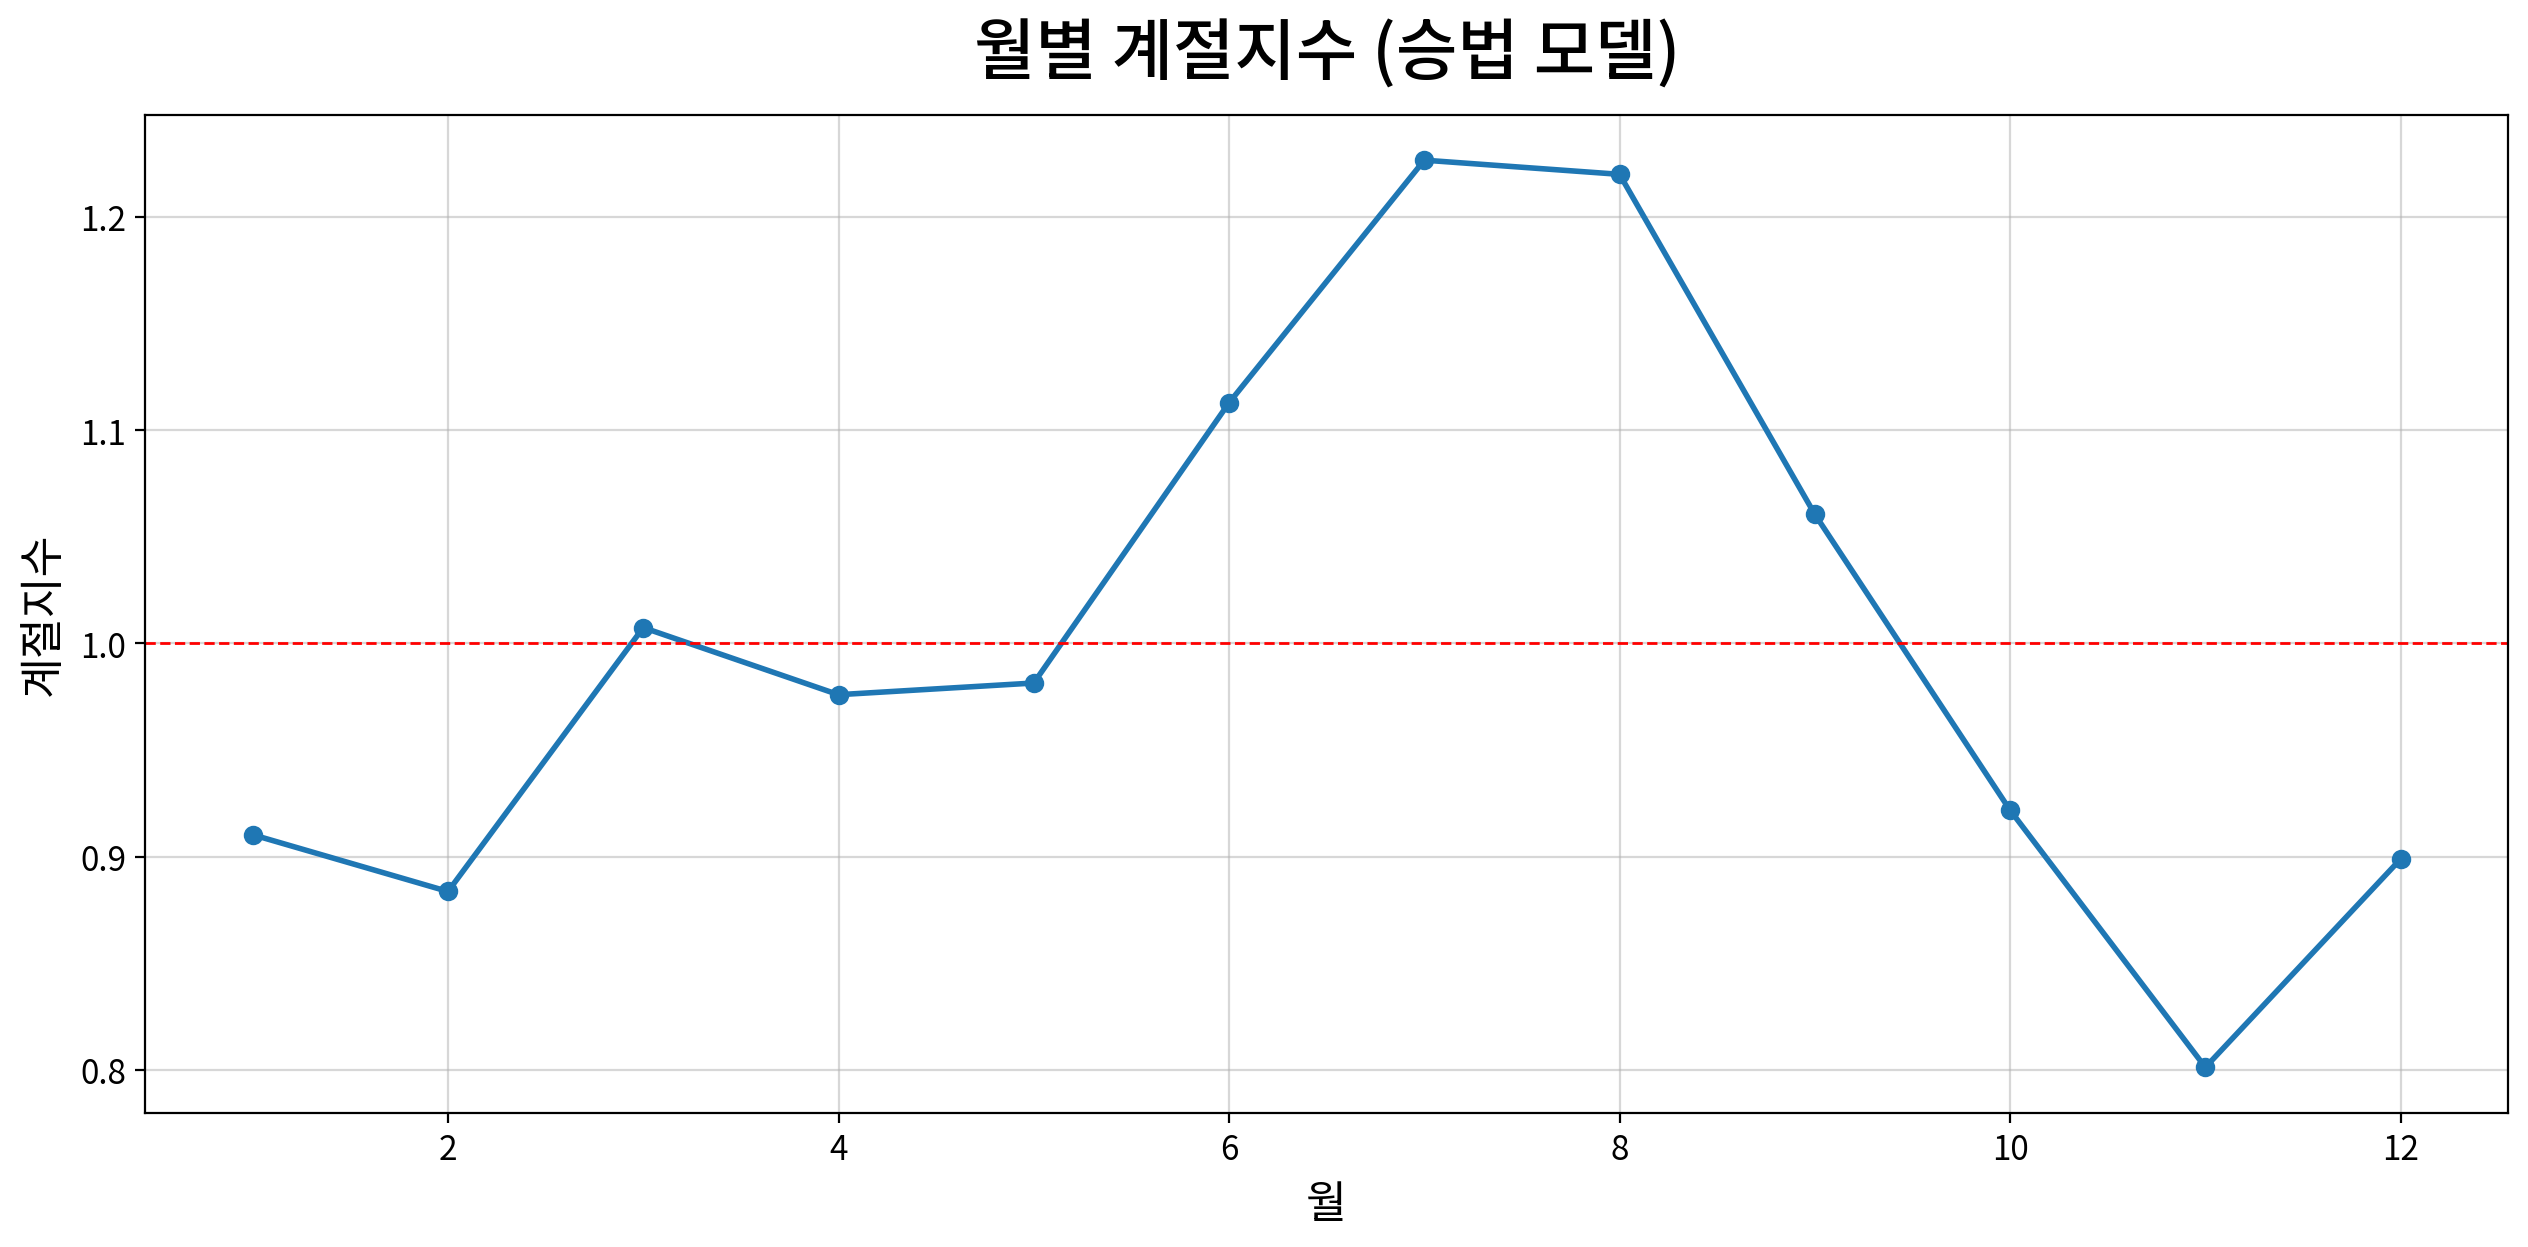

In [12]:
# 그래프 초기화
fig, ax = my_plot.init(title='월별 계절지수 (승법 모델)', xlabel='월', ylabel='계절지수')

# 캔버스(ax)에 추세 대비를 선 그래프로 표시
my_plot.lineplot(x=season.index, y=season.values, marker='o', ax=ax)

# 승법 모델 기준 평균선(=1)을 표시
ax.axhline(1, color='red', linestyle='--', linewidth=1)

# 그래프 화면 출력
my_plot.show()

(1) 성수기·비수기 구분

- **성수기**: 7월 1.227 · 8월 1.220 · 6월 1.113 · 9월 1.060
- **비수기**: 11월 0.801 · 2월 0.884 · 12월 0.899 · 1월 0.910 · 10월 0.922
- **중립**: 3월 1.007 · 5월 0.981 · 4월 0.976  
  → 계절 영향 거의 없음  
  → 중간은 추세·불규칙 요인으로 봐야 함

(2) 계절성의 진폭

- 1.227 ÷ 0.801 = **1.532배**
- 진폭이 클수록 계절조정 없이는 판단 불가

(3) 여름 한 덩어리

- 6~9월 넉 달 연속 1.0 초과
- 스파이크가 아닌 **두꺼운 성수기 구조**임

(4) 인접 달 비율

- 계절만으로 생기는 전월 대비 변화량

### 5. 계절 조정 시계열 만들기
- 원본에서 계절 성분을 걷어내면 계절 요인을 제거한 나머지 움직임이 남는다.

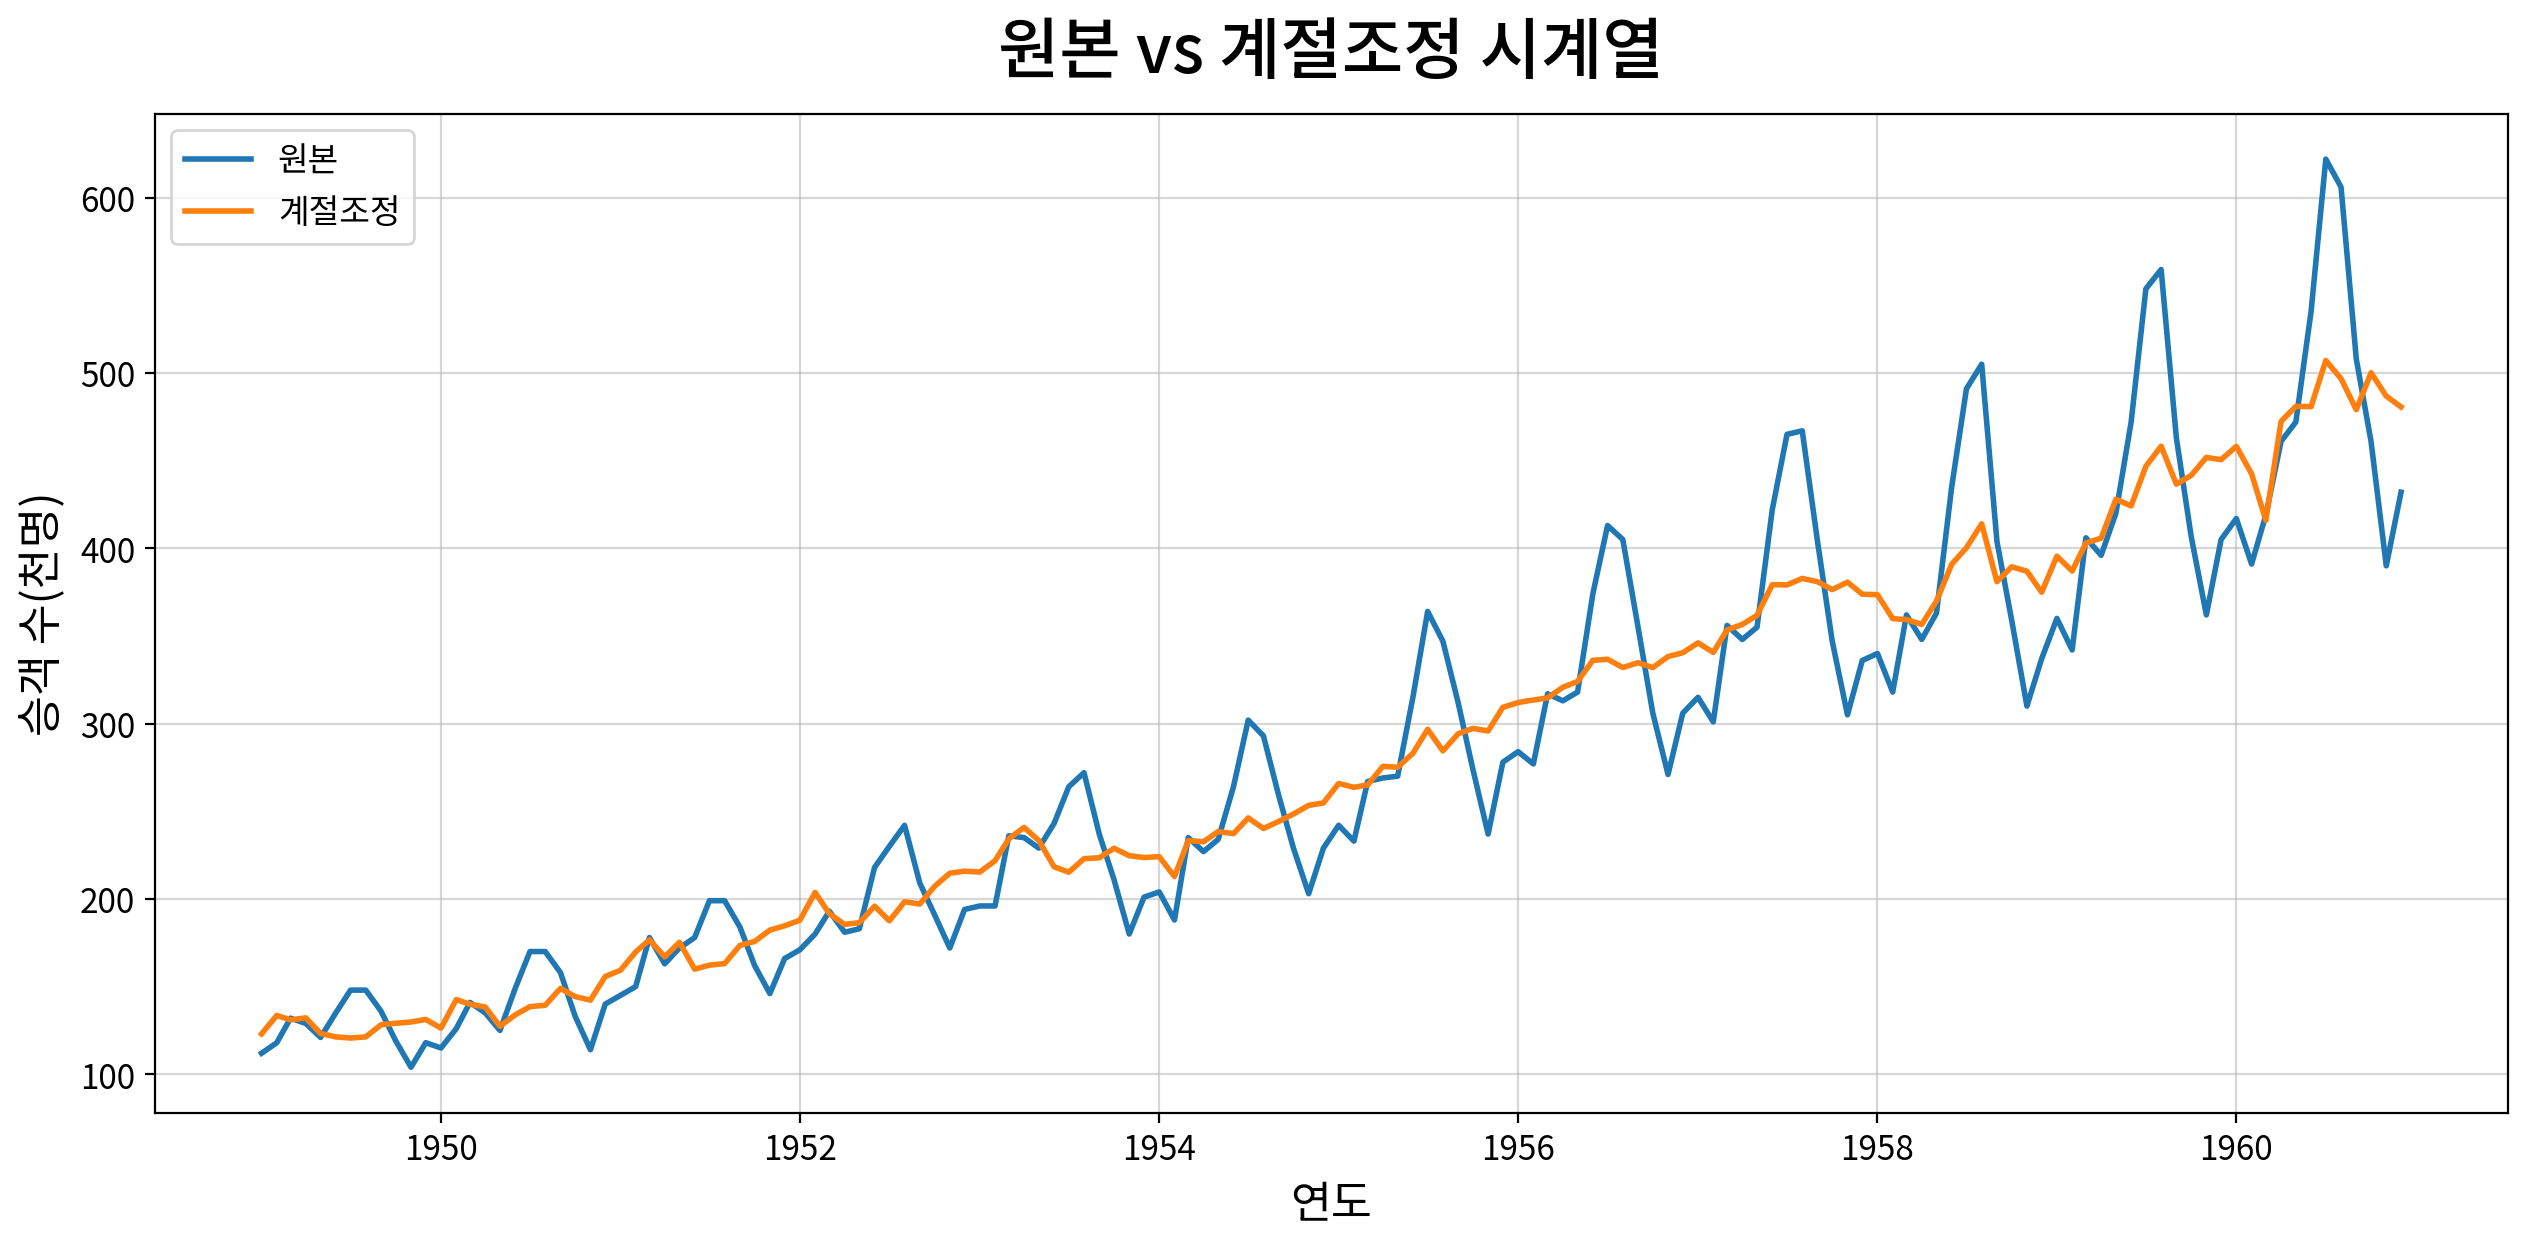

In [13]:
# 승법 모델이므로 나누기로 계절 성분을 제거한다 (가법이면 빼기)
adjusted = sd['original'] / sd['seasonal']

fig, ax = my_plot.init(title='원본 vs 계절조정 시계열', xlabel='연도', ylabel='승객 수(천명)')

my_plot.lineplot(x=df.index, y=df['Passengers'], label='원본', ax=ax)
my_plot.lineplot(x=adjusted.index, y=adjusted, label='계절조정', ax=ax)

ax.legend()
my_plot.show()

- 계절조정 시계열은 봉우리가 사라졌지만 이동평균처럼 매끈하지는 않다.
- 남은 울퉁불퉁함이 바로 잔차(불규칙요인)다.
- 계절조정 결과에서 갑자기 튀는 지점이 있다면 그 시점에 계절성으로 설명되지 않는 사건이 있었다는 뜻이다.
- 실무에서 이상 시점을 찾는 표준적인 방법이다.

## #04. 모듈화 기능 확인
### 1. 분해 시계열 생성

결합 방식 자동 판정: multiplicative
관측치 144개 중 추세·잔차가 계산된 구간 132개


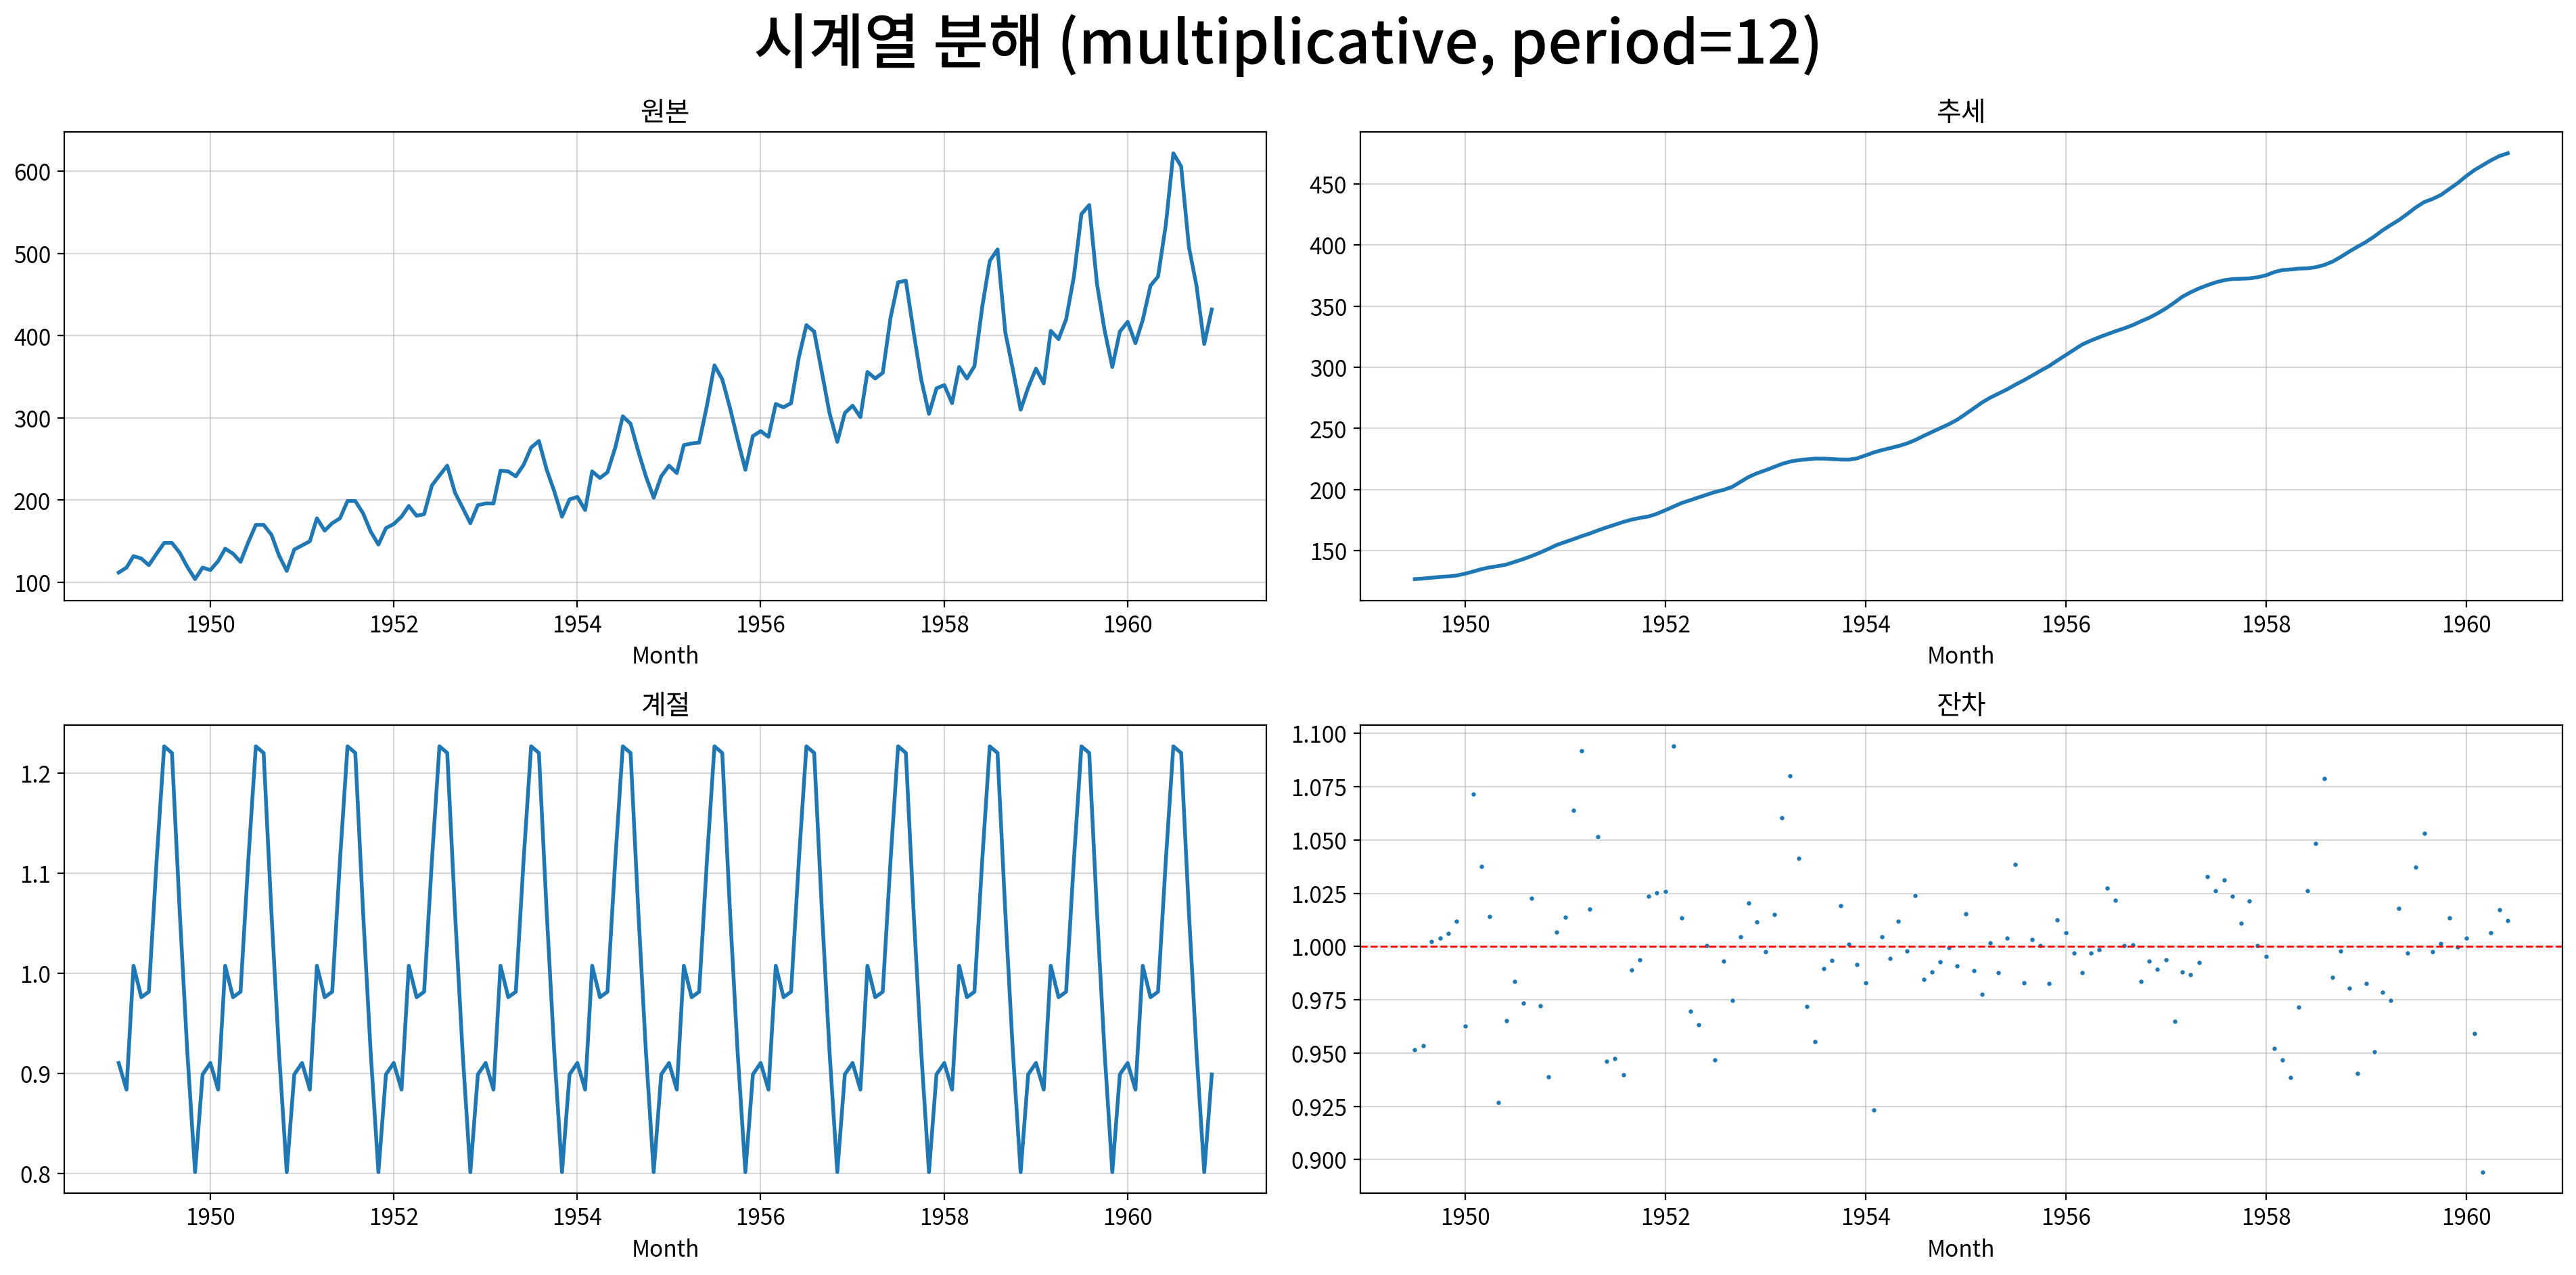

,원본,추세,계절,잔차
Month,,,,
1949-07-01,148.000,126.792,1.227,0.952
1949-08-01,148.000,127.250,1.220,0.953
1949-09-01,136.000,127.958,1.060,1.002


In [24]:
# model을 주지 않으면 가법/승법을 스스로 판정한다
result = my_ts.decompose(df, 12, "Passengers")

# 표는 화면에 뿌려지지 않고 반환되므로, 보고 싶으면 마지막 줄에 놓는다
result.dropna().head(3)

### 2. 계절지수

결합 방식: multiplicative
최고 위치: 7 (1.2266)
최저 위치: 11 (0.8012)


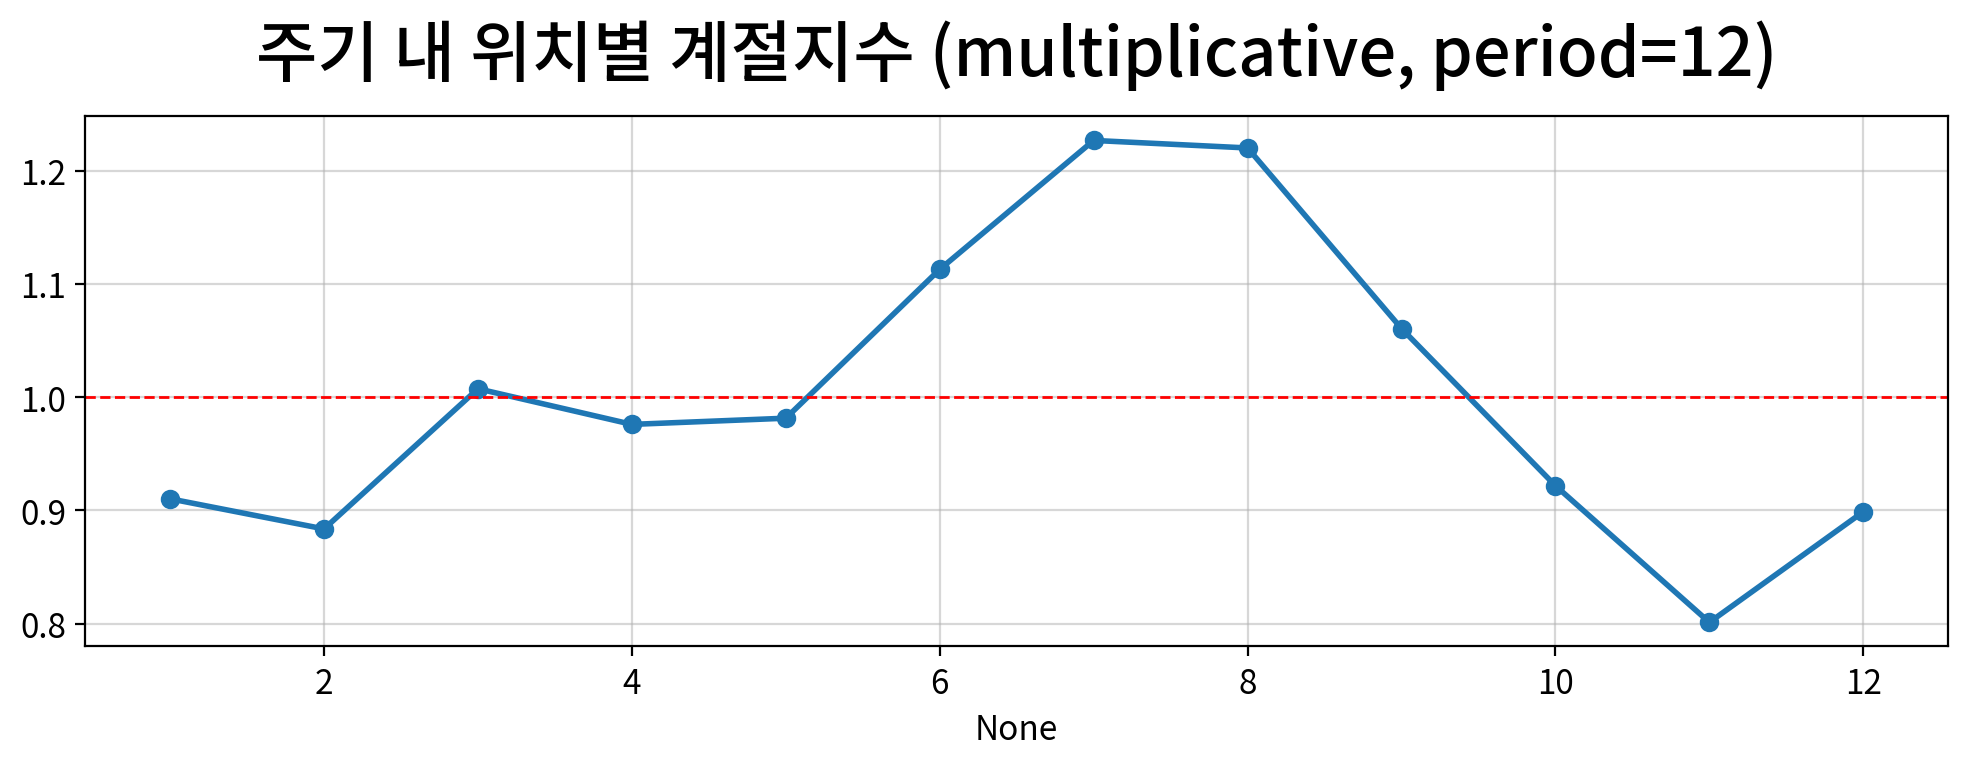

주기 내 위치,1,2,3,4,5,6,7,8,9,10,11,12
계절지수,0.910,0.884,1.007,0.976,0.981,1.113,1.227,1.220,1.060,0.922,0.801,0.899
평균,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
기준 대비(%),-9.000,-11.600,0.700,-2.400,-1.900,11.300,22.700,22.000,6.000,-7.800,-19.900,-10.100


In [15]:
ss=my_ts.report_seasonal(df, 12, "Passengers")
ss.T

### 3. 계절 조정

결합 방식: multiplicative (원본 ÷ 계절)


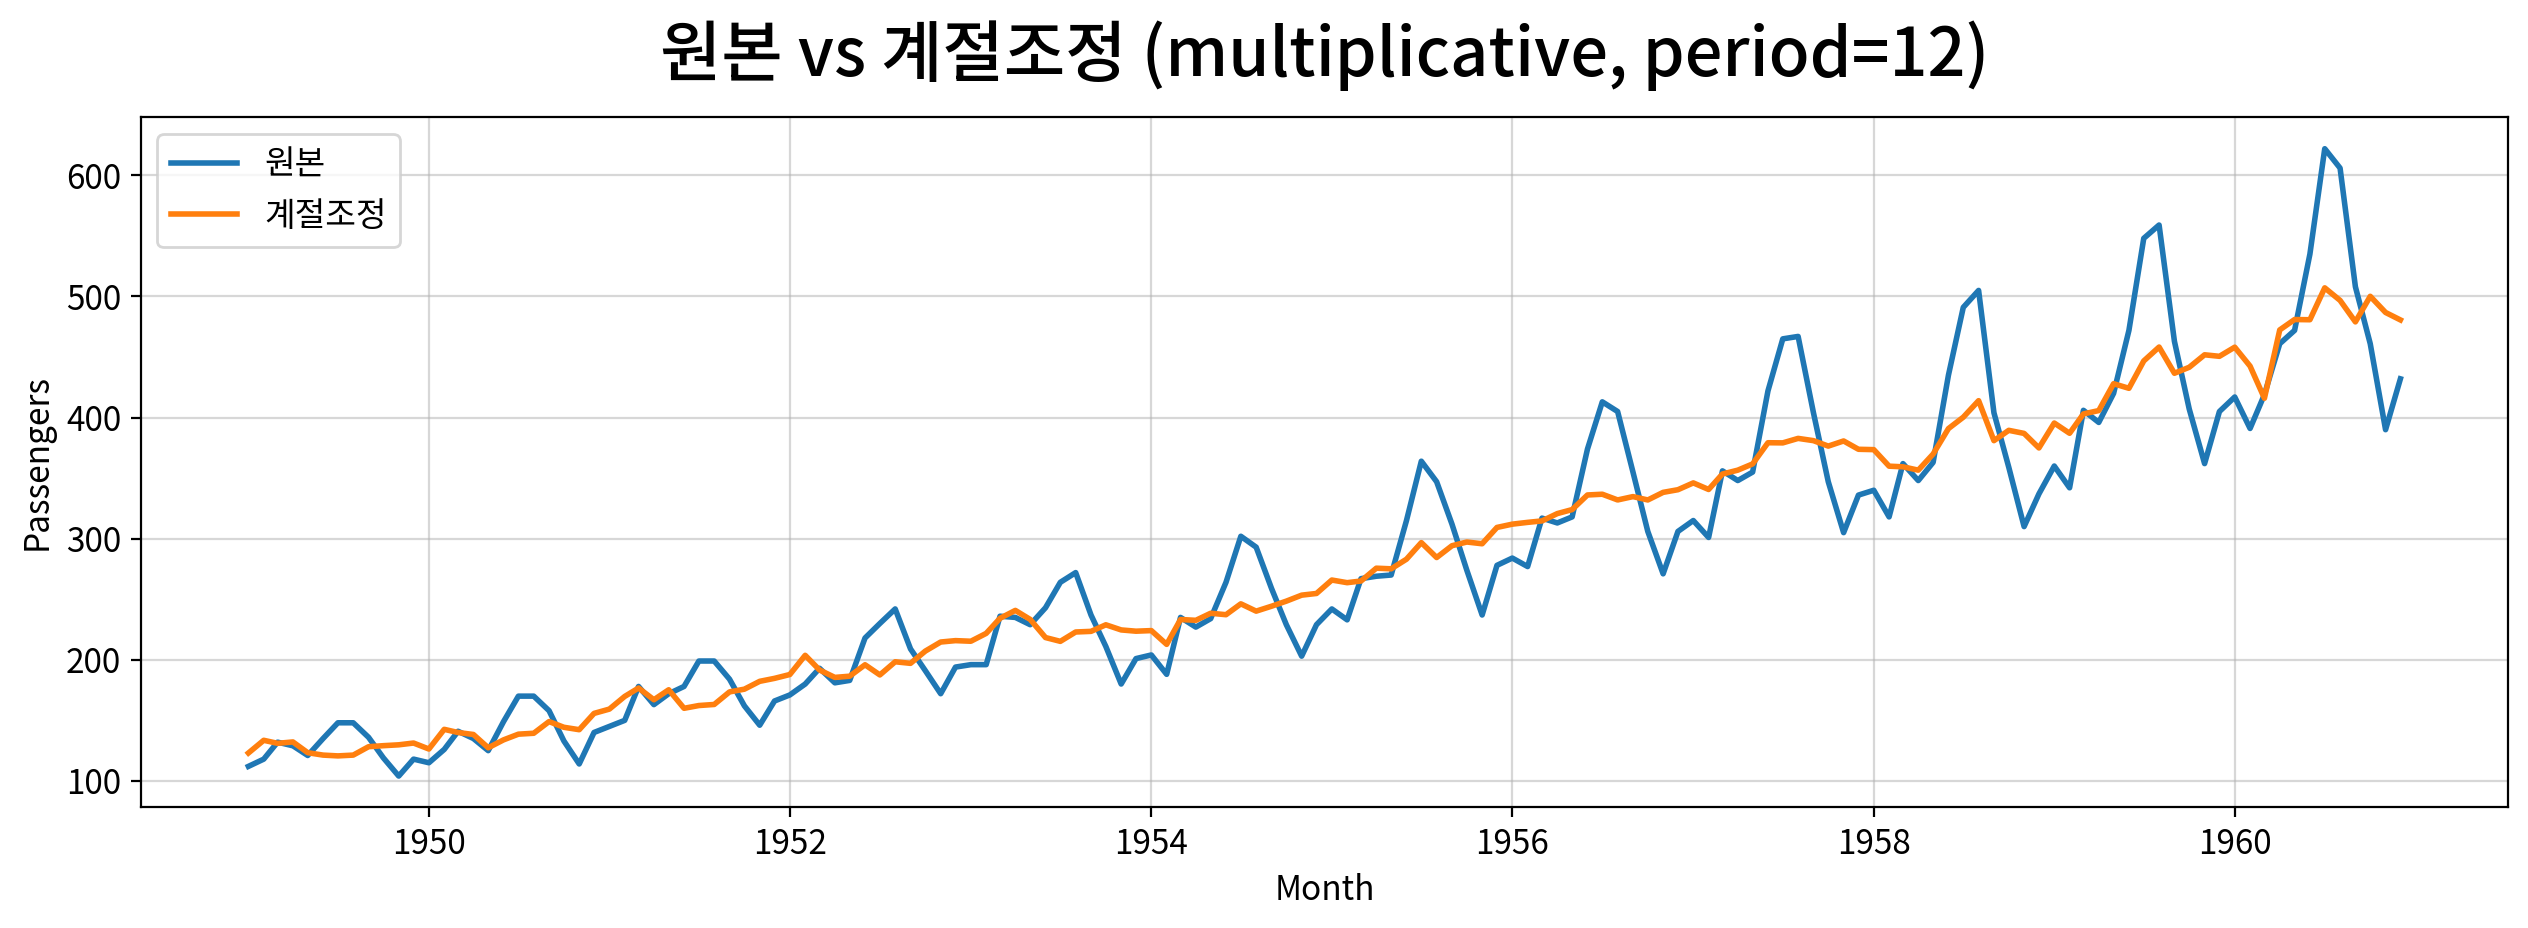

Month
1949-01-01   123.046
1949-02-01   133.541
1949-03-01   131.035
Freq: MS, dtype: float64

In [16]:
adjusted = my_ts.adjust_seasonal(df, 12, "Passengers")
adjusted.head(3)

## 연습문제 - 서울 기온 보고서 : 계절 탓인가, 정말 이상한 해였나
![alt text](image-19.png)

In [17]:
df1 = load_data('temperatures_seoul')
df1.head()

📚 1973년 1월부터 2023년 8월까지 서울의 월평균 기온 데이터 (출처: 기상청)


,날짜,평균기온(℃)
0,1973-07-01,26.816
1,1973-08-01,25.884
2,1973-09-01,20.323
3,1973-10-01,13.039
4,1973-11-01,4.723


In [18]:
# 월단위 데이터임을 알림 --> freq='MS' (Month Start)
df2 = my_ts.set_index(df1, '날짜', freq='MS')
print('인덱스 간격(freq):', df2.index.freqstr)
df2.head()

인덱스 간격(freq): MS


,평균기온(℃)
날짜,
1973-07-01,26.816
1973-08-01,25.884
1973-09-01,20.323
1973-10-01,13.039
1973-11-01,4.723


결합 방식 자동 판정: additive
관측치 602개 중 추세·잔차가 계산된 구간 590개


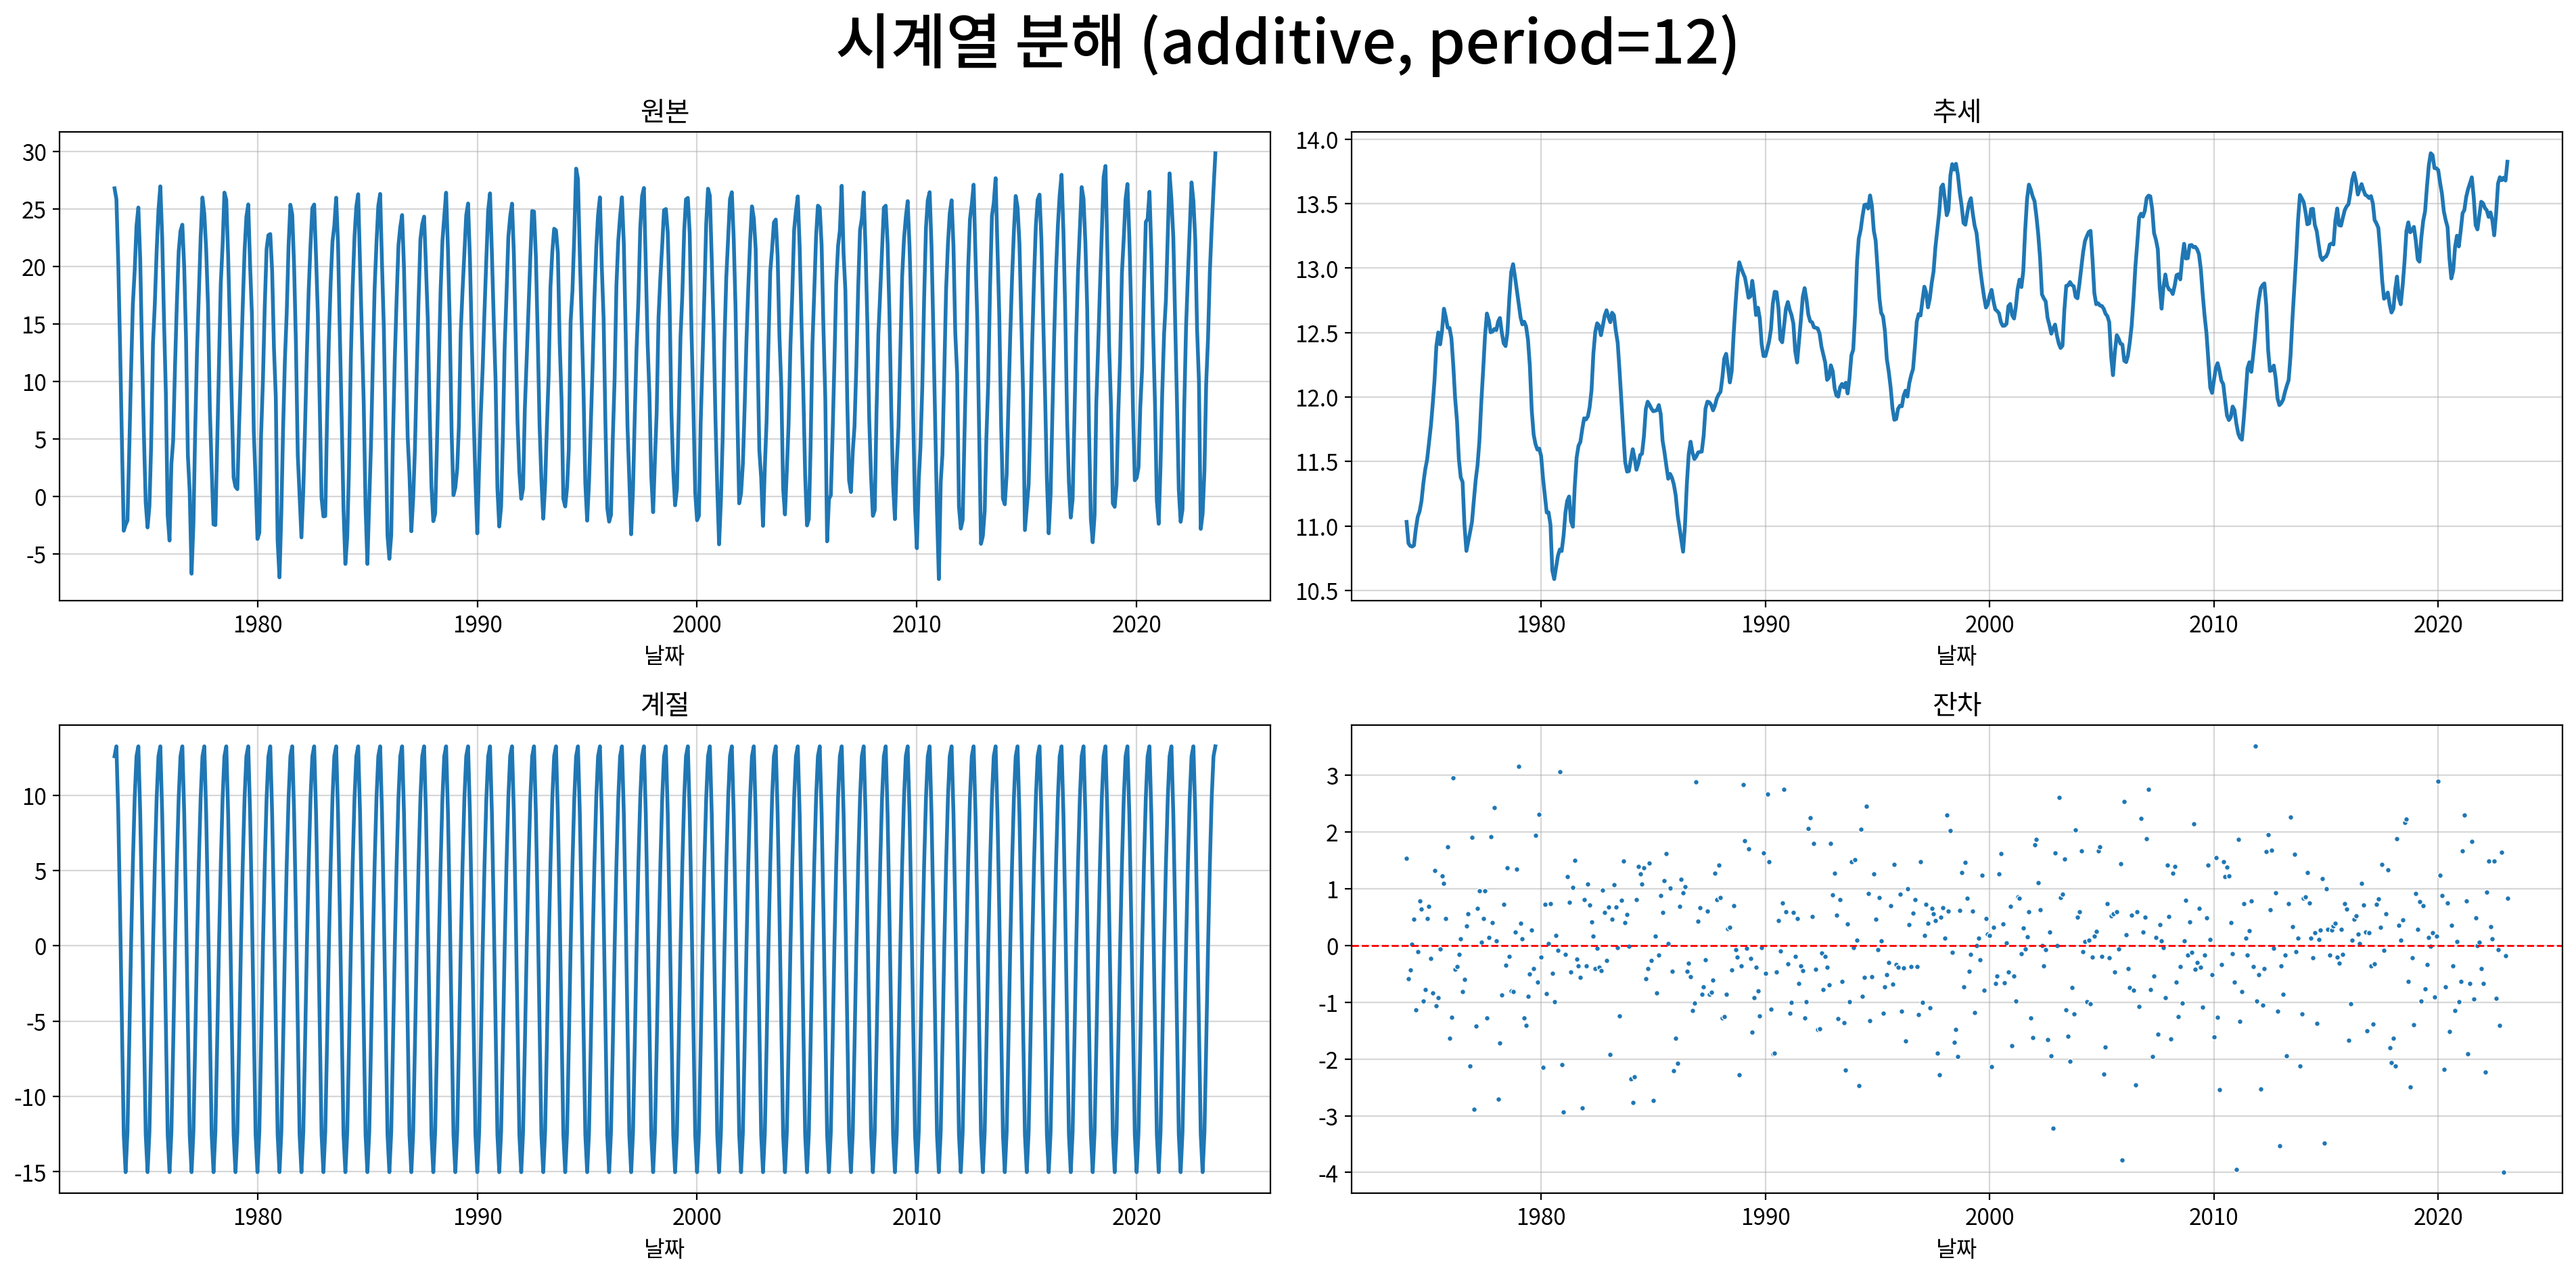

,원본,추세,계절,잔차
날짜,,,,
1974-01-01,-2.458,11.031,-15.024,1.535
1974-02-01,-2.079,10.864,-12.361,-0.582
1974-03-01,3.687,10.845,-6.728,-0.430
1974-04-01,10.720,10.840,-0.136,0.016
1974-05-01,16.665,10.849,5.360,0.456
...,...,...,...,...
2022-10-01,14.565,13.705,2.273,-1.414
2022-11-01,10.030,13.682,-5.288,1.635
2022-12-01,-2.816,13.702,-12.524,-3.994


In [25]:
# model을 주지 않으면 가법/승법을 스스로 판정한다
result1 = my_ts.decompose(df2, 12, "평균기온(℃)")

# 표는 화면에 뿌려지지 않고 반환되므로, 보고 싶으면 마지막 줄에 놓는다
result1.dropna()

In [26]:
result1["계절"].std().round(3)

np.float64(9.809)

결합 방식: additive
최고 위치: 2 (13.2459)
최저 위치: 7 (-15.0241)


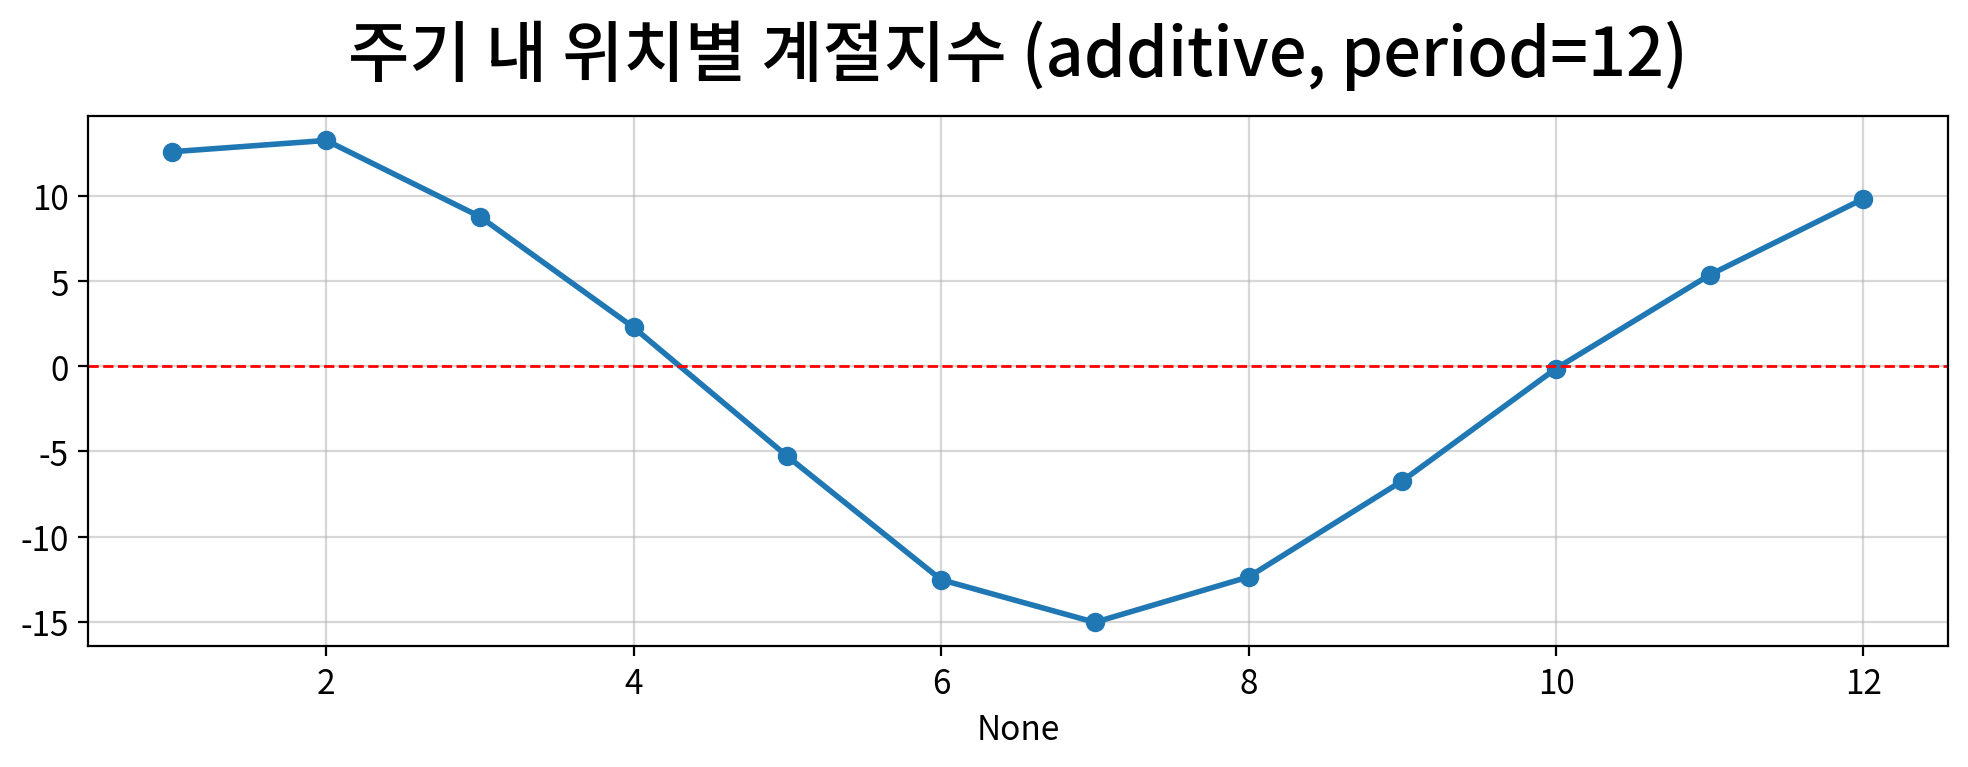

,7월,8월,9월,10월,11월,12월,1월,2월,3월,4월,5월,6월
계절지수,12.584,13.246,8.773,2.273,-5.288,-12.524,-15.024,-12.361,-6.728,-0.136,5.360,9.824
평균,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000
기준 대비,12.584,13.246,8.773,2.273,-5.288,-12.524,-15.024,-12.361,-6.728,-0.136,5.360,9.824


In [28]:
ss2 = my_ts.report_seasonal(df2, 12, "평균기온(℃)")

ss2.index = ["7월", "8월", "9월", "10월", "11월", "12월",
             "1월", "2월", "3월", "4월", "5월", "6월"]

ss2.T

In [29]:
print(-15.024 - 13.246)

-28.27


결합 방식: additive (원본 − 계절)


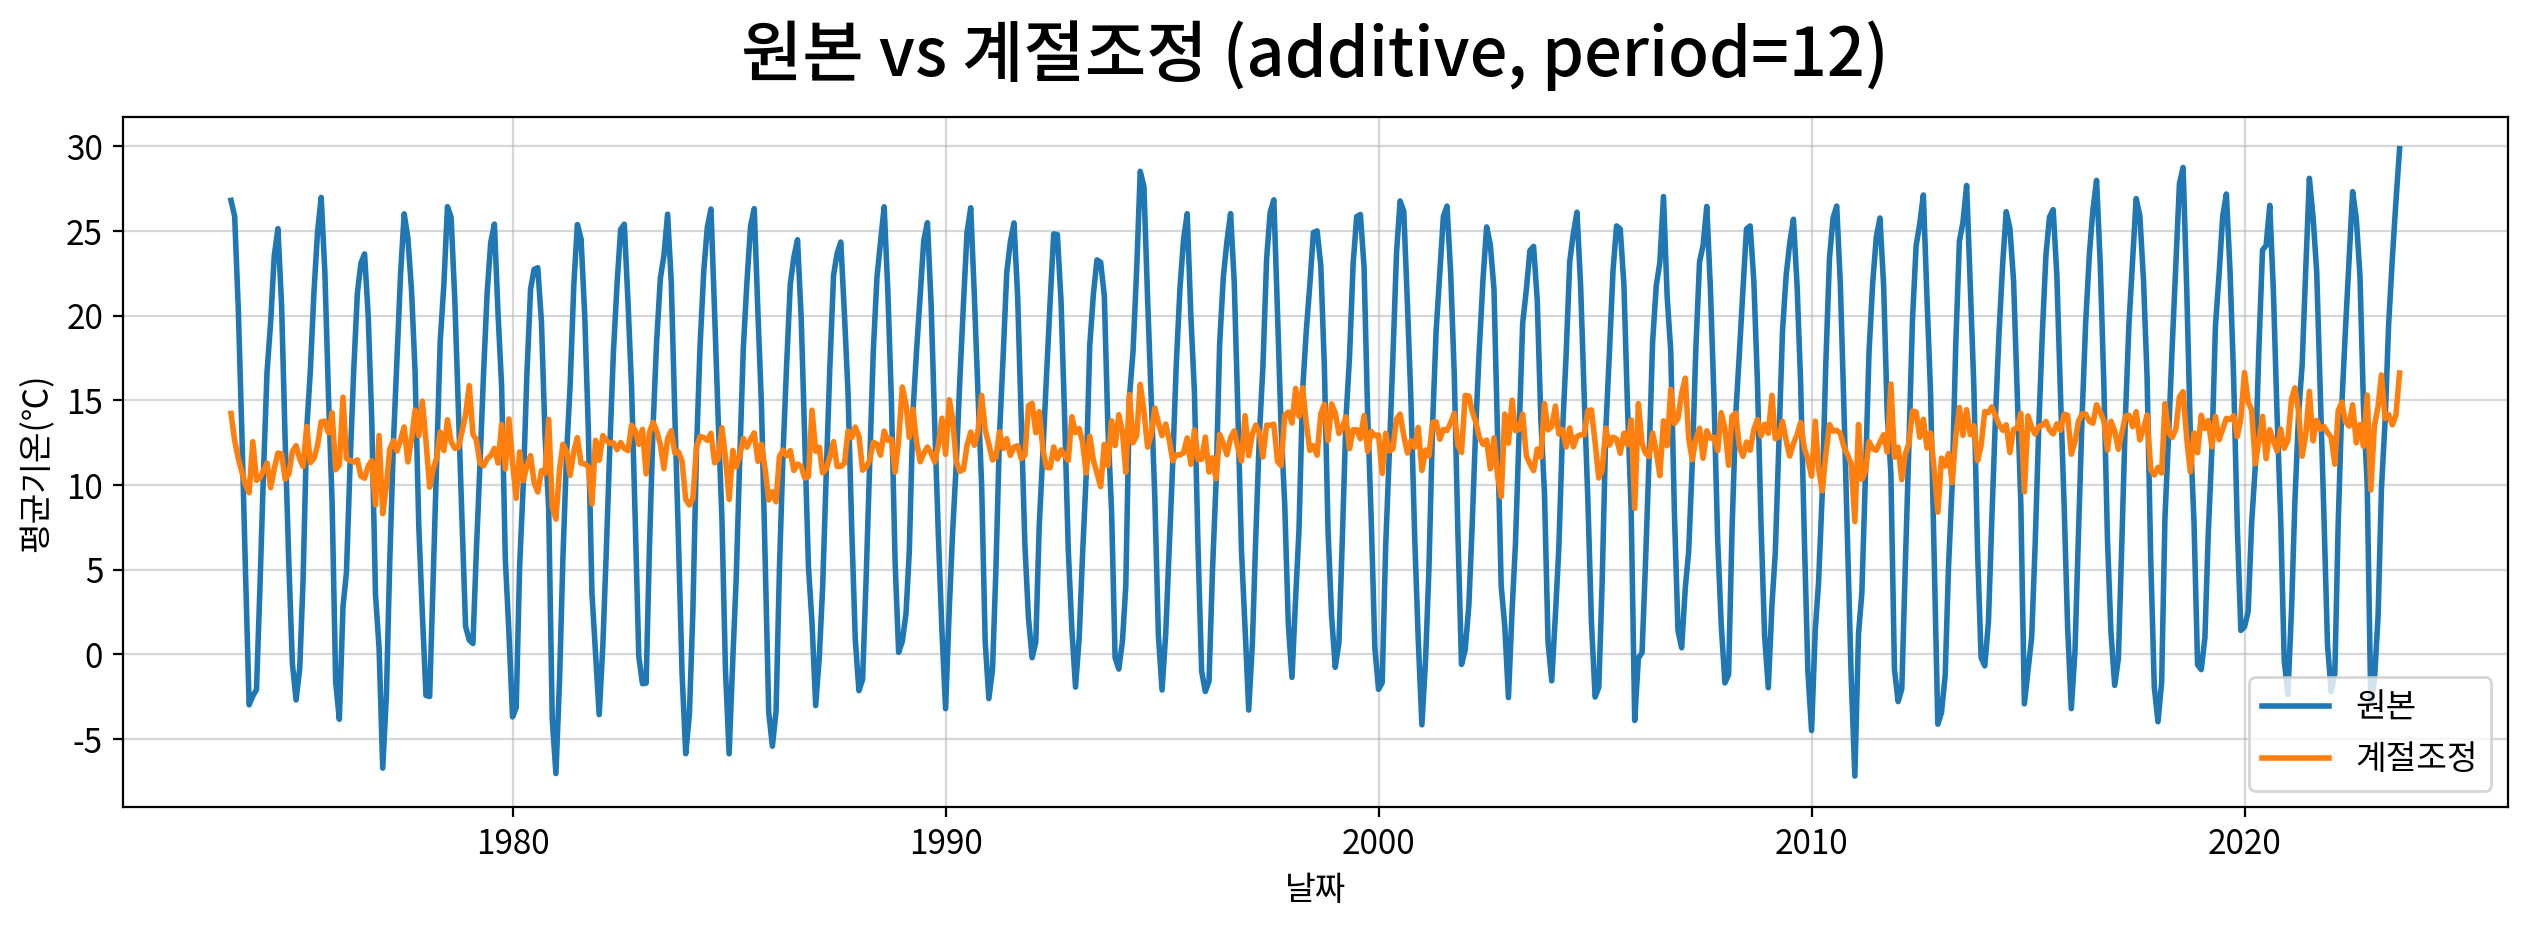

날짜
1973-07-01   14.232
1973-08-01   12.638
1973-09-01   11.550
Freq: MS, dtype: float64

In [27]:
adjusted2 = my_ts.adjust_seasonal(df2, 12, "평균기온(℃)")
adjusted2.head(3)

- 문제 1 : 가법 
- 문제 2 : 9.809
- 문제 3 : -15.024℃
- 문제 4 : 28.270℃
- 문제 5 : 590개
- 문제 6 : 계절 조정